## Configuramos LangChain con Groq (modelo gratuito)

In [ ]:
# La integración de Groq con LangChain y LangGraph
!pip install -U langchain-groq langchain

In [ ]:
from langchain_groq import ChatGroq
from google.colab import userdata

GROQ_API_KEY = userdata.get('GROQ_API_KEY')

print("Api key de Groq cargada")

# El modelo que usarán todos los agentes (Groq)
model = ChatGroq(
    model="llama-3.1-8b-instant",
    api_key=GROQ_API_KEY
)

print("Modelo de Groq cargado")

Api key de Groq cargada
Modelo de Groq cargado


In [ ]:
!pip install langgraph

## Creamos State donde se guardará la información usada por los nodos

In [ ]:
from langgraph.graph import StateGraph, START, END
from IPython.display import Image, display
from typing_extensions import TypedDict, Annotated
from pydantic import BaseModel, Field

# En esta clase se van guardando la información
# que irán usando los distintos nodos de LangGraph
class State(TypedDict):
  query: str
  model_calls: int
  research_info: str
  is_info_relevant: bool
  improved_query: str
  email: str


## Creamos los nodos de LangGraph
Los nodos ejecutarán las llamadas al modelo, cada nodo tiene una función específica distinta. En nuestro caso estos nodos:
- **Researcher**: busca información en internet a partir de la consulta del usuario.
- **Evaluator**: comprueba que la información obtenida es válida, verídica y suficiente. Enruta el workflow, si acepta el resultado, lo envía al siguiente nodo y si no, vuelve a llamar al nodo de búsqueda.
- **Writer**: con la información, construye un correo electrónico para enviar al usuario.

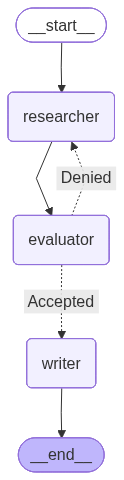

is_info_relevant=False improved_query='Resumen de películas taquilleras en 2014'
is_info_relevant=True improved_query='¿Cuáles fueron las películas más taquilleras de 2014?'
Aquí te presento un ejemplo de código HTML para una newsletter que resume las películas taquilleras de 2014:

```html
<!DOCTYPE html>
<html>
<head>
	<meta charset="UTF-8">
	<title>Resumen de películas taquilleras en 2014</title>
	<style>
		body {
			font-family: Arial, sans-serif;
			margin: 0;
			padding: 0;
		}
		
		.container {
			max-width: 600px;
			margin: 0 auto;
			padding: 20px;
			background-color: #f4f4f4;
		}
		
		.header {
			background-color: #333;
			color: #fff;
			padding: 20px;
			text-align: center;
		}
		
		.header h1 {
			margin: 0;
		}
		
		.content {
			padding: 20px;
		}
		
		.content ul {
			list-style: none;
			padding: 0;
			margin: 0;
		}
		
		.content ul li {
			padding: 10px;
			border-bottom: 1px solid #ccc;
		}
		
		.content ul li:last-child {
			border-bottom: none;
		}
		
		.conten

In [ ]:
# -- Nodo que busca información --
# TODO: funcionalidad, ahora solo genera información falsa
def researcher(state: State):
  """El modelo crea una lista de reviews falsas"""

  msg = None

  # Si no es la primera vez que se llama al modelo, repite la búsqueda
  # con una consulta creada por el nodo evaluador
  if state.get('improved_query'):
    msg = model.invoke(state['improved_query'])
  else:
    msg = model.invoke(f"repite bla bla bla 20 veces")

  return {"research_info": msg.content, "model_calls": state.get('model_calls', 0) + 1}

# -- Nodo que evalúa si se puede completar el email con la información obtenida --

# Una clase para estructurar la respuesta del modelo evaluador
class Feedback(BaseModel):
  is_info_relevant: bool = Field(description="Si la información obtenida es suficiente para responder la pregunta, el valor es True, si no es suficiente, es False")
  improved_query: str = Field(description="Consulta que responderá la pregunta correctamente")

evaluator_model = model.with_structured_output(Feedback)

def evaluator(state: State):
  """El modelo verifica si puede completar el email con la información obtenida"""

  feedback = evaluator_model.invoke(f"""Verifica si la información obtenida: {state['research_info']} es suficiente para responder esta pregunta del usuario verídicamente {state['query']}""")
  print(feedback)
  return {"is_info_relevant": feedback.is_info_relevant, "improved_query": feedback.improved_query, "model_calls": state.get('model_calls', 0) + 1}

def router(state: State):
  """Termina el programa o vuelve a buscar información si no ha sido suficiente la obtenida anteriormente"""

  if state['is_info_relevant']:
    return "Accepted"
  else:
    return "Denied"

# -- Nodo que escribe el contenido del email --
def writer(state: State):
  """El modelo crea un email con la información obtenida"""

  msg = model.invoke(f"""Sabiendo que la consulta del usuario es esta: {state['query']},
  crea código HTML formateado para un correo electrónico modelizado como una newsletter utilizando esta información: {state['research_info']}""")
  return {"email": msg.content, "model_calls": state.get('model_calls', 0) + 10}

# Construimos el workflow que tendrán los agentes al enviar el prompt
movie_email_builder = StateGraph(State)

# Añadimos los nodos con las llamadas al modelo
movie_email_builder.add_node("researcher", researcher)
movie_email_builder.add_node("evaluator", evaluator)
movie_email_builder.add_node("writer", writer)

# Unimos, relacionamos, los nodos
movie_email_builder.add_edge(START, "researcher")
movie_email_builder.add_edge("researcher", "evaluator")
movie_email_builder.add_conditional_edges("evaluator", router, {"Accepted": "writer", "Denied": "researcher"})
movie_email_builder.add_edge("writer", END)

# Visualizar el movie_email_builder gráficamente
movie_email_workflow = movie_email_builder.compile()
display(Image(movie_email_workflow.get_graph().draw_mermaid_png()))

msg = movie_email_workflow.invoke({"query": "Resumen de películas taquilleras en 2014"})
print(msg['email'])